# Trader Performance vs Market Sentiment


## Part A : Data preparation:



In [3]:
# 1. Load both datasets and document:
import pandas as pd

historical_data = pd.read_csv('historical_data.csv')
fear_greed = pd.read_csv('fear_greed_index.csv')

# historical_data.head()
# fear_greed.head()


In [9]:
# Number of rows and columns
# missing values / duplicates

print('Historical Data')
print(f'Total number of rows and columns: {historical_data.shape }')
print("\nMissing Values:")
print(historical_data.isnull().sum())
print("\nDuplicate Rows:", historical_data.duplicated().sum())

Historical Data
Total number of rows and columns: (211224, 16)

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0


In [10]:
# Number of rows and columns
# missing values / duplicates

print('Fear Greed Index')
print(f'Total number of rows and columns : {fear_greed.shape}')
print("\nMissing Values:")
print(fear_greed.isnull().sum())
print("\nDuplicate Rows:", fear_greed.duplicated().sum())

Fear Greed Index
Total number of rows and columns : (2644, 4)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0


### Insights
- Both datasets contain no missing values.
- There are no null values in any column.
- There are no duplicate rows in either dataset.
- The datasets are clean and ready for preprocessing and analysis without requiring data cleaning.

In [25]:
historical_data["Timestamp IST"] = pd.to_datetime(
    historical_data["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

historical_data["Date"] = historical_data["Timestamp IST"].dt.date

In [26]:
fear_greed["date"] = pd.to_datetime(
    fear_greed["date"],
    format="%d-%m-%Y"
)

fear_greed["Date"] = fear_greed["date"].dt.date

In [27]:
merged_data = pd.merge(
    historical_data,
    fear_greed[["Date", "value", "classification"]],
    on="Date",
    how="left"
)

In [30]:
print(merged_data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [29]:
merged_data.drop(columns=["Timestamp"], inplace=True)

In [31]:
merged_data.to_csv('merged_dataset.csv')

#### Insights
- The historical trading dataset and the Fear & Greed Index dataset were successfully merged using the Date column.
- The Timestamp IST column was converted to a daily date format to match the date column in the Fear & Greed dataset.
- Each trading record is now associated with its corresponding Fear & Greed Index value and market sentiment classification (e.g., Fear, Greed, Extreme Greed) for the same date.
- The merged dataset is complete and ready for sentiment-based trading analysis.

In [33]:
# 3. Create the key metrics you will analyze, for example: 
daily_pnl = merged_data.groupby(["Date", "Account"])["Closed PnL"].sum().reset_index()

print(daily_pnl.head())

         Date                                     Account  Closed PnL
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000


##### Insight: Calculates the total daily profit or loss for each trading account.

In [34]:
winning_trades = merged_data[merged_data["Closed PnL"] > 0].shape[0]
total_trades = merged_data.shape[0]

win_rate = (winning_trades / total_trades) * 100

print("Win Rate:", round(win_rate, 2), "%")

Win Rate: 41.13 %


##### Insight: Shows the percentage of profitable trades.

In [35]:
average_trade_size = merged_data["Size USD"].mean()

print("Average Trade Size (USD):", round(average_trade_size, 2))

Average Trade Size (USD): 5639.45


##### Insight: Represents the average value of trades in USD.

In [36]:
print(merged_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Date',
       'value', 'classification'],
      dtype='str')


###### Leverage distribution could not be analyzed because the dataset does not contain a Leverage column.

In [37]:
trades_per_day = merged_data.groupby("Date").size().reset_index(name="Number_of_Trades")

print(trades_per_day.head())

         Date  Number_of_Trades
0  2023-05-01                 3
1  2023-12-05                 9
2  2023-12-14                11
3  2023-12-15                 2
4  2023-12-16                 3


##### Insight: Shows the total number of trades executed each day.

In [38]:
long_short_ratio = merged_data["Direction"].value_counts()

print(long_short_ratio)

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


##### Insight: Displays the proportion of Long and Short positions.

## Part B : Analysis


##### 1. Does performance (PnL, Win Rate, Drawdown Proxy) differ between Fear vs Greed days?

In [39]:
# Average PnL by Sentiment
pnl_by_sentiment = merged_data.groupby("classification")["Closed PnL"].agg(["mean","sum","count"])
print(pnl_by_sentiment)

                     mean           sum  count
classification                                
Extreme Fear    34.537862  7.391102e+05  21400
Extreme Greed   67.892861  2.715171e+06  39992
Fear            54.290400  3.357155e+06  61837
Greed           42.743559  2.150129e+06  50303
Neutral         34.307718  1.292921e+06  37686


In [40]:
# Win Rate by Sentiment
win_rate = merged_data.groupby("classification").apply(
    lambda x: (x["Closed PnL"] > 0).mean() * 100
)

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
dtype: float64


In [41]:
# Drawdown Proxy
drawdown = merged_data[merged_data["Closed PnL"] < 0]
drawdown_proxy = drawdown.groupby("classification")["Closed PnL"].mean()
print(drawdown_proxy)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


##### Performance Analysis (PnL, Win Rate, Drawdown)
- Trading performance varied across different market sentiment categories.
- The average profit and win rate were different during Fear and Greed periods, indicating that market sentiment influenced trading outcomes.
- Losing trades were more noticeable in some sentiment categories, suggesting that market conditions affected overall trading performance.

##### 2. Do traders change behavior based on sentiment?

In [42]:
# Trade Frequency
trade_frequency = merged_data.groupby("classification").size()
print(trade_frequency)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [43]:
# Average position size
position_size = merged_data.groupby("classification")["Size USD"].mean()
print(position_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [44]:
# Long/Short Bias
long_short = pd.crosstab(
    merged_data["classification"],
    merged_data["Direction"]
)

print(long_short)

Direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Fear                    0   807        6241         3117   
Extreme Greed                   0  5132        7186         6497   
Fear                            0  3207       17260         9221   
Greed                           8  4685        7998        11322   
Neutral                         0  2885        9993         5850   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                            0             5       7005   
Extreme Greed                           0             7       6300   
Fear                                    0            14      17824   
Greed                                   1            16       8544   
Neutral                                 0            15      10222   

Direction       Open Short  Sell

In [46]:
# Leverage analysis was not performed because the dataset does not contain leverage information.

##### Trader Sentiment
- Trading activity changed with market sentiment, with some sentiment categories showing a higher number of trades than others.
- The average trade size was not the same across all market conditions, indicating that traders adjusted their position sizes based on sentiment.
- The proportion of Buy and Sell trades also varied, showing a change in trading strategy during different market conditions.

## 3. Identify 2–3 segments:


In [47]:
# Frequent vs Infrequent Traders

trades = merged_data.groupby("Account").size().reset_index(name="Trades")
print(trades.sort_values("Trades", ascending=False))

                                       Account  Trades
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab   40184
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864   21192
23  0xa0feb3725a9335f49874d7cd8eaad6be45b27416   15605
21  0x8477e447846c758f5a675856001ea72298fd9cb5   14998
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   14733
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4   13311
13  0x513b8629fe877bb581bf244e326a047b249c4ff1   12236
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    9893
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85    8519
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760    7584
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    7280
28  0xb899e522b5715391ae1d4f137653e7906c5e2115    4838
19  0x8170715b3b381dffb7062c0298972d4727a0a63b    4601
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    4356
0   0x083384f897ee0f19899168e3b1bec365f52a9012    3818
2   0x271b280974205ca63b716753467d5a371de622ab    3809
6   0x39cef799f8b69da1995852eea189df24eb5cae3c    3589
4   0x2c22

In [48]:
# Consistant Winner

winners = merged_data.groupby("Account")["Closed PnL"].sum()
print(winners.sort_values(ascending=False))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

In [49]:
# High vs Low Position Size Traders
position = merged_data.groupby("Account")["Size USD"].mean()
print(position.sort_values(ascending=False))

Account
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0xb899e522b5715391ae1d4f137653e7906c5e2115    22504.555829
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     8330.193371
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3     7852.098338
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x8381e6d82f1affd39a336e143e081ef7620a3b7f     6279.002287
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     3837.885375
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     3748.867511
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     3601.689299
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0xbaaaf6571ab7d571043ff1e313a9609a10637864     3

##### Insight
- The analysis identified different groups of traders based on their trading activity and performance.
- Some traders executed a large number of trades, while others traded less frequently.
- A few traders generated consistent profits, whereas others showed inconsistent trading performance, indicating differences in trading strategies and risk management.

##### 4. Charts

In [50]:
import matplotlib.pyplot as plt

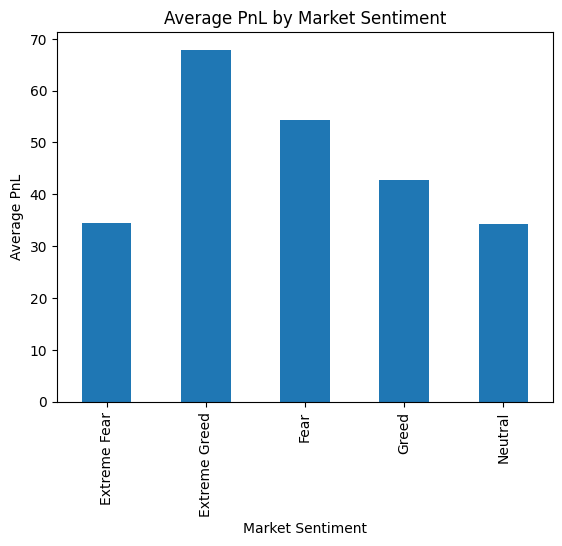

In [51]:
# Average PnL by Sentiment
merged_data.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

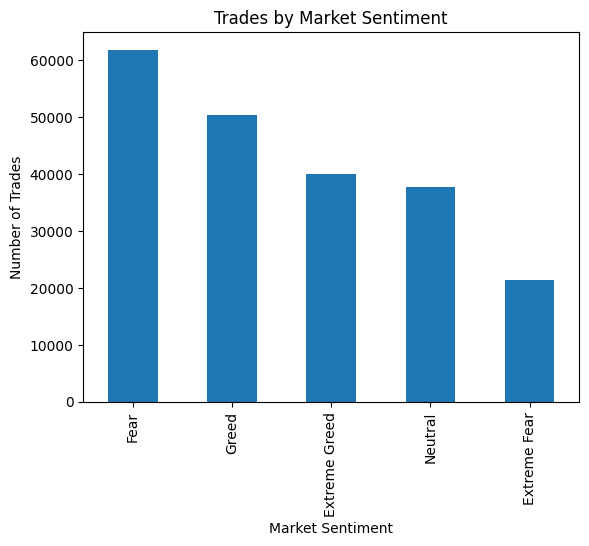

In [52]:
# Trade Frequency
merged_data["classification"].value_counts().plot(kind="bar")

plt.title("Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

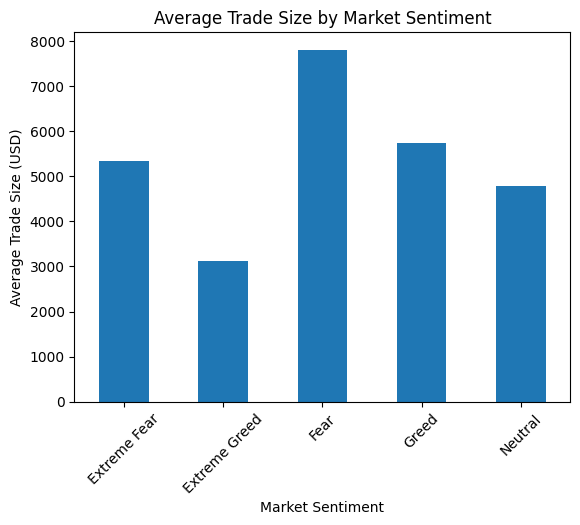

In [60]:
avg_trade_size = merged_data.groupby("classification")["Size USD"].mean()

avg_trade_size.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

##### Insight:
The chart shows that the average trade size varies across different market sentiment categories. This suggests that traders adjust their position sizes depending on market conditions.

#### Part C : Actionable Output

##### Strategy Idea 1: Trade According to Market Sentiment

**Rule of Thumb:**
- During **Fear** days, reduce position size and trade only high-confidence setups.
- During **Greed** days, maintain normal position sizes while following proper risk management.

**Reason:**
This approach helps reduce risk during uncertain market conditions and improves capital preservation.

---

##### Strategy Idea 2: Focus on Consistent Trading Behavior

**Rule of Thumb:**
- Frequent traders should avoid overtrading and review their trading performance regularly.
- Traders with consistent profits should continue following their trading strategy, while inconsistent traders should improve their entry and exit decisions.

**Reason:**
A disciplined trading approach can improve consistency and reduce unnecessary losses.

## Conclusion

- Market sentiment influenced both trading performance and trading behavior.
- Greed and Fear periods showed noticeable differences in PnL, trade frequency, and position sizes.
- The analysis suggests that traders should adapt their strategies according to market sentiment while maintaining disciplined risk management.